# Import Libraries

In [36]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# Problem

The function

$$
C(t) = 1.35te^{-2.802t}
$$

models the average BAC, measured in mg/mL, of a group of eight male subjects $t$ hours after rapid consumption of $15$ mL of ethanol (corresponding to one alcoholic drink). What is the maximum average BAC during the first 3 hours? When does it occur?

# Analysis 

From our analysis (please check Lecture Notes for topic 3.1 Absolute Extreme), the maximum occurs at $t = -1/b$

In [37]:
# Define symbols
# We assume a > 0 and b < 0 (for elimination/decay)
a, b, t = sp.symbols('a b t', real=True)

# Define the function C(t) = a * t * e^(b*t)
C = a * t * sp.exp(b * t)

#Calculate the First Derivative C'(t)
C_prime = sp.diff(C, t)
print(f"First Derivative: {sp.simplify(C_prime)}")

#Find Critical Numbers (solve C'(t) = 0)
critical_points = sp.solve(C_prime, t)
print(f"Critical Number: t = {critical_points[0]}")

#Calculate the Second Derivative C''(t) for SDT
C_double_prime = sp.diff(C_prime, t)
print(f"Second Derivative: {sp.simplify(C_double_prime)}")

#Evaluate C''(t) at the critical point
sdt_value = C_double_prime.subs(t, critical_points[0])
print(f"SDT value at peak: {sp.simplify(sdt_value)}")

First Derivative: a*(b*t + 1)*exp(b*t)
Critical Number: t = -1/b
Second Derivative: a*b*(b*t + 2)*exp(b*t)
SDT value at peak: a*b*exp(-1)


# Define the function for Plotting

$$
C(t) = ate^{bt}
$$

where $a = 1.35$ and $b = -2.802$.

Time at which C(t) is maximum: 0.36 hours


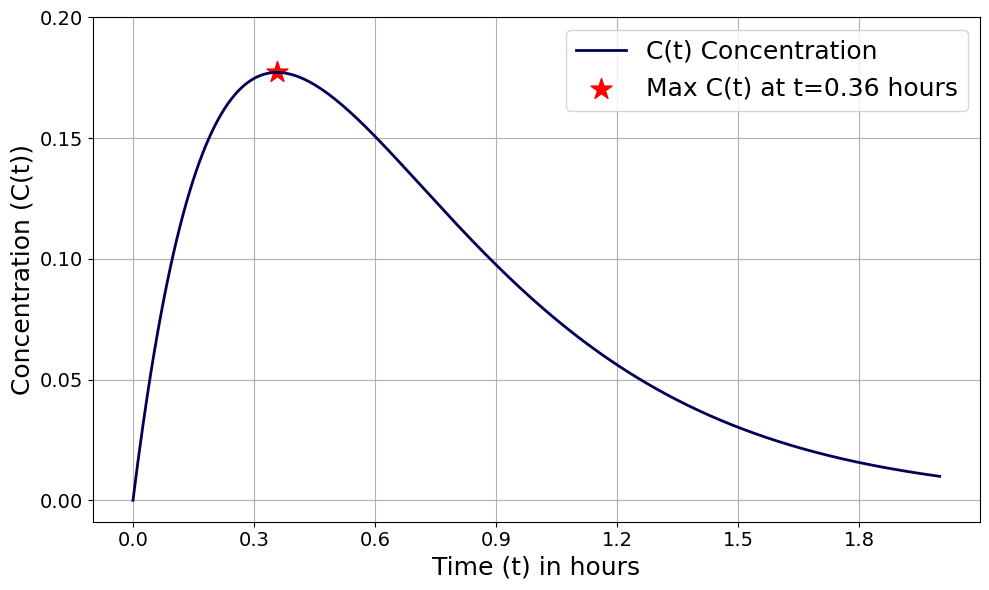

In [44]:
#Define the function C(t) for plotting
def C(a,b,t):
    '''
    --> need to for plotting since sympy is not compatible with numpy arrays
    --> we can also use this part to define the parameters of our function parang
    ganito sa baba:

    This function calculates the concentration C(t) based on the parameters a, b, and time t.
    Parameters:
    a (float): A positive constant representing the initial concentration factor.
    b (float): A negative constant representing the elimination rate.
    t (float or array-like): Time in hours at which to calculate the concentration.
    Returns:
    float or array-like: The concentration C(t) at the given time(s).
    '''
    output = a * t * np.exp(b * t)
    return output

##Set parameters for plotting
t = np.linspace(0, 2, 500) ## --> discretize natin si time from range from 0 to 2 hours with 500 points para smooth yung curve
a = 1.35
b = -2.802
t_max = -1/b
print(f"Time at which C(t) is maximum: {t_max:.2f} hours")

###Plotting
plt.figure(figsize=(10, 6))
plt.plot(t, C(a, b, t), color="#000055", label="C(t) Concentration", linewidth=2)
plt.scatter(t_max, C(a, b, t_max), color="#FF0000", marker='*', s = 250, label=f'Max C(t) at t={t_max:.2f} hours')
plt.legend(loc="upper right", fontsize=18)
xticks = np.arange(0, 2, 0.3)
plt.xticks(xticks, fontsize=14)
yticks = np.arange(0, 0.25, 0.05)
plt.yticks(yticks, fontsize=14)
plt.xlabel("Time (t) in hours", fontsize=18)
plt.ylabel("Concentration (C(t))", fontsize=18)
plt.grid(True)
plt.tight_layout()
# plt.savefig("BAC_plot.png", dpi=600)
plt.show()